# Anomaly injection

Real series are punctuated by spikes, dips, and sustained level shifts — sensor glitches, promotions, outages. Any SynForecast generator can inject these on demand, so you can measure how a model or an anomaly detector behaves when they appear, with the exact locations known in advance.

::: {.callout-tip}
## Ground-truth labels

Set `exogenous=ExogenousConfig(anomaly_flags=True)` and the output gains an `anomaly_flag` column marking every injected point. That turns a synthetic series into a labelled benchmark for detection methods. The plots below use it to highlight the injected anomalies in red.
:::

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.exogenous import ExogenousConfig
from synforecast.generators import RandomWalkGenerator, SeasonalGenerator, VARGenerator

FLAGS = ExogenousConfig(anomaly_flags=True)


def plot_anomalies(df, title):
    """Plot each series and mark injected anomalies (anomaly_flag == 1) in red."""
    fig, ax = plt.subplots(figsize=(11, 4))
    multi = df["unique_id"].n_unique() > 1
    for uid in df["unique_id"].unique(maintain_order=True).to_list():
        s = df.filter(pl.col("unique_id") == uid).sort("ds")
        ax.plot(s["ds"], s["y"], linewidth=1, alpha=0.8, label=str(uid))
        hits = s.filter(pl.col("anomaly_flag") == 1)
        ax.scatter(hits["ds"], hits["y"], color="crimson", s=25, zorder=3,
                   label="injected" if not multi else None)
    ax.set(title=title, xlabel="ds", ylabel="y")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Point anomalies: spikes and dips

Spikes and dips are single-point outliers. `anomaly_fraction` sets how many points are affected; `spike_magnitude` and `dip_magnitude` set their size (in the series' own units).

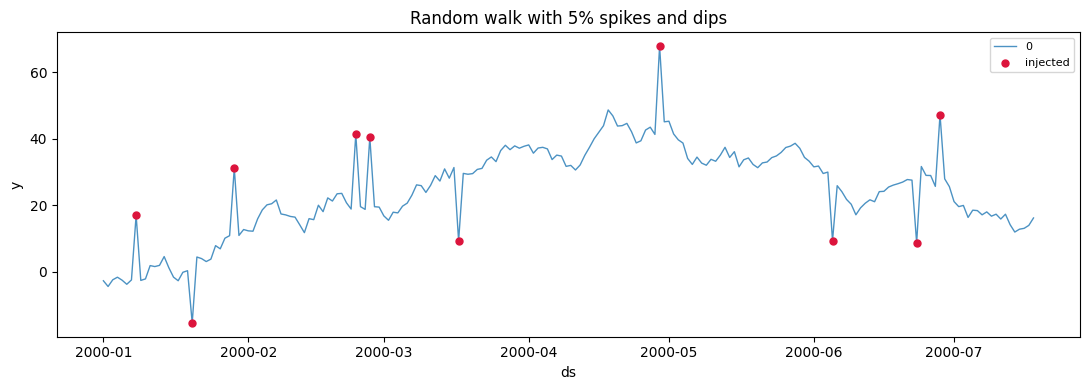

In [ ]:
point_gen = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    drift=0.1,
    volatility=2.0,
    anomalies=True,
    anomaly_fraction=0.05,
    anomaly_types=["spike", "dip"],
    spike_magnitude=20.0,
    dip_magnitude=-20.0,
    exogenous=FLAGS,
    seed=42,
)
point_df = point_gen.generate(n_series=1)
plot_anomalies(point_df, "Random walk with 5% spikes and dips")

Each red marker is an injected outlier that departs sharply from the local trend, then the series resumes as if nothing happened — the signature of a point anomaly.

## Level shifts

A level shift is a *sustained* jump: the series steps to a new level and stays there for `level_shift_duration` steps. These are harder for models than isolated spikes because they look like a regime change.

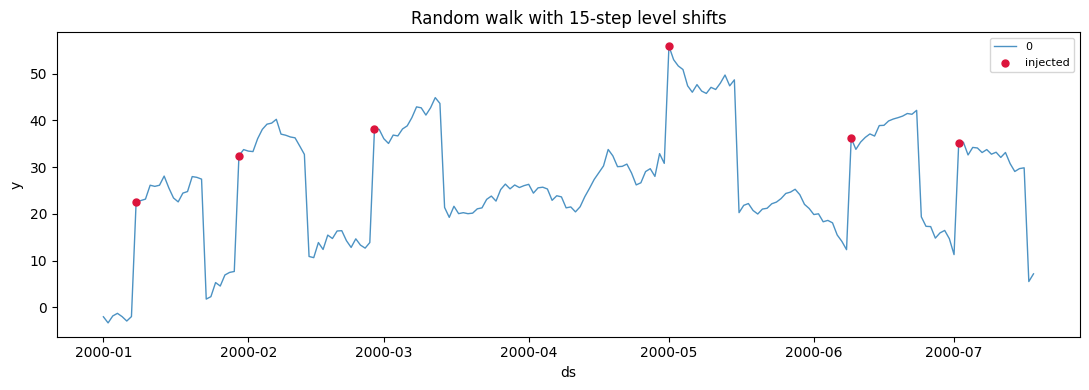

In [ ]:
shift_gen = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    drift=0.05,
    volatility=1.5,
    anomalies=True,
    anomaly_fraction=0.03,
    anomaly_types=["level_shift"],
    level_shift_magnitude=25.0,
    level_shift_duration=15,
    exogenous=FLAGS,
    seed=42,
)
plot_anomalies(shift_gen.generate(n_series=1), "Random walk with 15-step level shifts")

The flagged region marks where each shift begins; the elevated plateau that follows is the sustained deviation.

## On any generator, including multivariate

Anomaly injection is part of the shared generator pipeline, so it works the same on a seasonal series or a multivariate `VAR`, where each channel is perturbed independently.

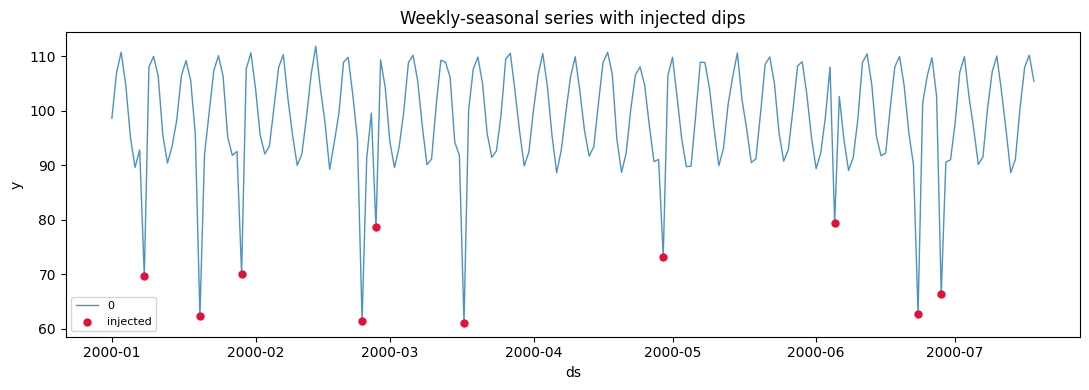

In [ ]:
seasonal_df = SeasonalGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    seasonality_period=7,
    seasonality_amplitude=10.0,
    base_level=100.0,
    anomalies=True,
    anomaly_fraction=0.05,
    anomaly_types=["dip"],
    dip_magnitude=-30.0,
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
plot_anomalies(seasonal_df, "Weekly-seasonal series with injected dips")

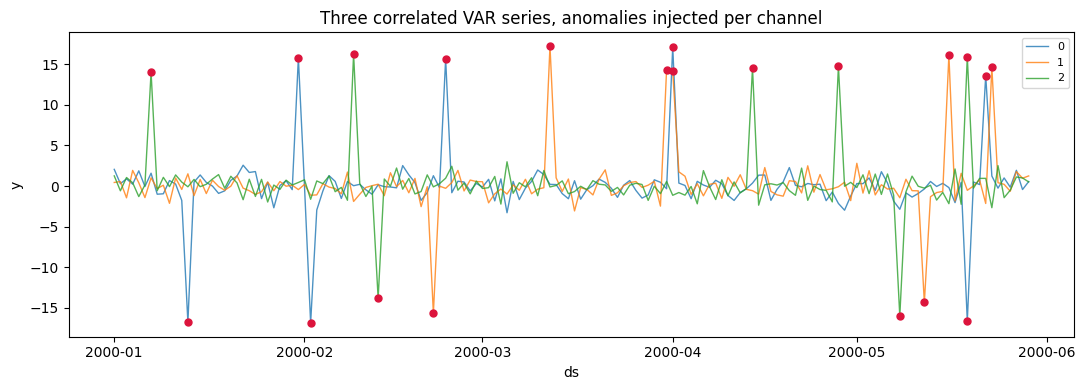

In [ ]:
var_df = VARGenerator(
    engine="polars",
    min_length=150,
    max_length=150,
    freq="D",
    lag_order=1,
    anomalies=True,
    anomaly_fraction=0.05,
    anomaly_types=["spike", "dip"],
    spike_magnitude=15.0,
    dip_magnitude=-15.0,
    exogenous=FLAGS,
    seed=42,
).generate(n_series=3)
plot_anomalies(var_df, "Three correlated VAR series, anomalies injected per channel")

## Combine with missing data

Anomalies and missing values compose, so you can build a realistically messy series in one call — outliers to detect *and* gaps to impute.

missing values: 0 of 200


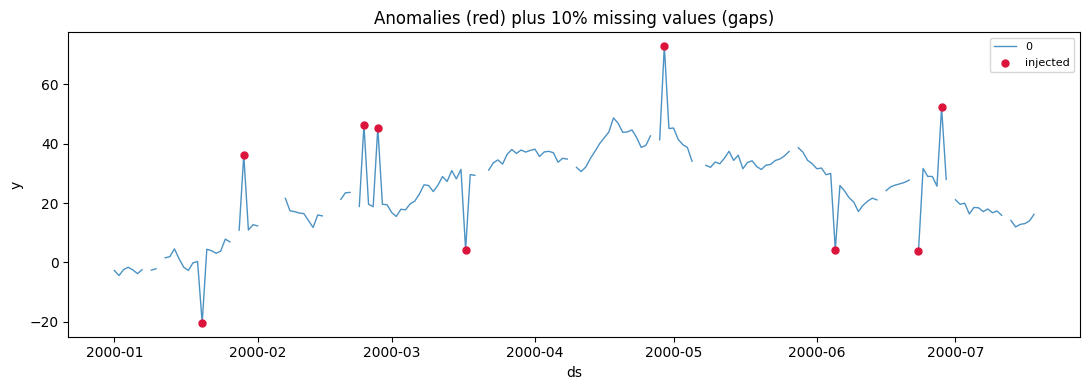

In [ ]:
messy_df = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    drift=0.1,
    volatility=2.0,
    anomalies=True,
    anomaly_fraction=0.05,
    anomaly_types=["spike", "dip"],
    spike_magnitude=25.0,
    dip_magnitude=-25.0,
    missing_data=True,
    missing_pattern="random",
    missing_rate=0.1,
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
print(f"missing values: {messy_df['y'].null_count()} of {len(messy_df)}")
plot_anomalies(messy_df, "Anomalies (red) plus 10% missing values (gaps)")

::: {.callout-note}
## Related capabilities

- [Changepoints](changepoints) — structural breaks in level, trend, or variance (a modelled regime change rather than an anomaly).
- [Missingness](missingness) — random, block, and seasonal gap patterns.
- The magnitudes and durations here are the common knobs; every anomaly parameter is listed in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::